### Simple MultAI Agent Architecture

In [1]:

import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver



C:\Users\lenovo\AppData\Local\Temp\ipykernel_11052\2202442965.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:

from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver


In [4]:
class AgentState(MessagesState):
    next_agent:str

In [5]:
@tool 
def search_web(query:str)->str:
    """Search the web for the query and return a summary of the results."""

    #USing TavilySearchResults to search the web
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)

    return str(results)

@tool
def write_summary(text:str)->str:
    """Write a summary of the given text."""
    return f"Summary: {text[:100]}..."

In [6]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:llama-3.1-8b-instant")

llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002123B4703E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002123B5BC650>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [12]:
# Define agent functions

def research_agent(state:AgentState)->str:
    """Agent that researches the topic and returns a summary."""

    messages = state["messages"]

    #Add System Message for context
    sys_msg = SystemMessage(content="You are a research agent. Your task is to research the topic and return a summary.")

    # Call llm with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke(messages + [sys_msg])

    return {
        "messages":response,
        "next_agent":"writer_agent"
    }

In [13]:
def writer_agent(state:AgentState)->str:
    """Agent that writes a summary based on the research."""

    messages = state["messages"]

    #Add System Message for context
    sys_msg = SystemMessage(content="You are a writing agent. Your task is to write a summary based on the research.")

    # Call llm with tools
    response = llm.invoke(messages + [sys_msg])

    return {
        "messages":[response],
        "next_agent":"end"
    }

In [14]:

# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

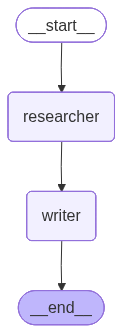

In [15]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", research_agent)
workflow.add_node("writer", writer_agent)

# Define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow=workflow.compile()

final_workflow

In [17]:
response = final_workflow.invoke({"messages":"Research about ai agents and write a summary."})

In [18]:
response["messages"][-1].content

"**Summary: The Rise of AI Agents**\n\nArtificial Intelligence (AI) agents have revolutionized the way we interact with technology, and their presence is increasingly felt across various industries. AI agents are computer programs designed to perform specific tasks, often autonomously, using machine learning algorithms and natural language processing (NLP). Here's a summary of the key findings from our research:\n\n**Types of AI Agents:**\n\n1. **Virtual Assistants:** AI agents like Siri, Alexa, and Google Assistant have become ubiquitous, enabling users to perform tasks, access information, and control smart devices with voice commands.\n2. **Chatbots:** Programmed to simulate human-like conversations, chatbots are used in customer service, e-commerce, and other applications to provide support and assistance.\n3. **Predictive Models:** AI agents can analyze data to predict outcomes, identify patterns, and make informed decisions, improving efficiency and productivity in industries lik